# Batch Parameter Management

This notebook demonstrates how to read and modify HMS basin parameters in bulk
using DataFrames. Instead of looping element-by-element, you can:

1. **Export** all parameters to a DataFrame or CSV
2. **Edit** in Excel, pandas, or any tabular tool
3. **Import** changes back with automatic backup and validation

| Method | Purpose |
|--------|---------|
| `get_all_loss_parameters()` | Read loss params for ALL subbasins |
| `get_all_transform_parameters()` | Read transform params for ALL subbasins |
| `get_all_baseflow_parameters()` | Read baseflow params for ALL subbasins |
| `get_all_routing_parameters()` | Read routing params for ALL reaches |
| `set_all_*_parameters()` | Write modified DataFrame back to file |
| `export_parameters_csv()` | Export to CSV for Excel editing |
| `import_parameters_csv()` | Import CSV back to basin file |
| `HmsMet.set_all_gage_assignments()` | Batch update gage assignments |

**Estimated Time**: 10 minutes

In [1]:
# pip install hms-commander

**For Development**: If working on hms-commander source code, use the `hmscmdr_local`
conda environment (editable install) instead of pip install.

In [2]:
import shutil
from pathlib import Path
import pandas as pd
from hms_commander import HmsExamples, HmsBasin, HmsMet


import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("hms_commander").setLevel(logging.WARNING)


def display_path(path, base=None):
    path = Path(path)
    base = Path.cwd() if base is None else Path(base)
    try:
        return path.resolve().relative_to(base.resolve()).as_posix()
    except Exception:
        return path.name

print("hms-commander loaded")

hms-commander loaded


## 1. Extract Example Project

We use the **tenk** (Tenkiller Lake) project which has 4 subbasins with
Initial+Constant loss, Modified Clark transform, Recession baseflow,
and 5 reaches with Modified Puls and Lag routing.

In [3]:
# Extract a fresh copy for this notebook
project_path = HmsExamples.extract_project(
    "tenk",
    output_path=Path.cwd() / 'hms_example_projects' / 'tenk_batch'
)

# Find the basin file
basin_file = next(Path(project_path).glob('*.basin'))
print(f"Basin file: {basin_file.name}")

Basin file: Tenk_1.basin


## Model Context

Before editing parameters, inspect the Tenkiller sample's basin elements, routing network, meteorologic model, control specifications, and parameter methods. This gives the tabular batch edits hydrologic context and verifies the notebook is operating on a complete routed basin.

,Component,Count,Details
0,Basin file,1,Tenk_1.basin
1,Subbasins,4,Total area 1611.00 sq mi
2,Reaches,5,Explicit routing reaches
3,Junctions,5,Confluences and outlet junctions
4,Reservoirs,0,Storage elements
5,Sinks,0,Terminal outlets
6,Meteorologic models,1,Stage3_HRAP
7,Control specs,1,Jan_96


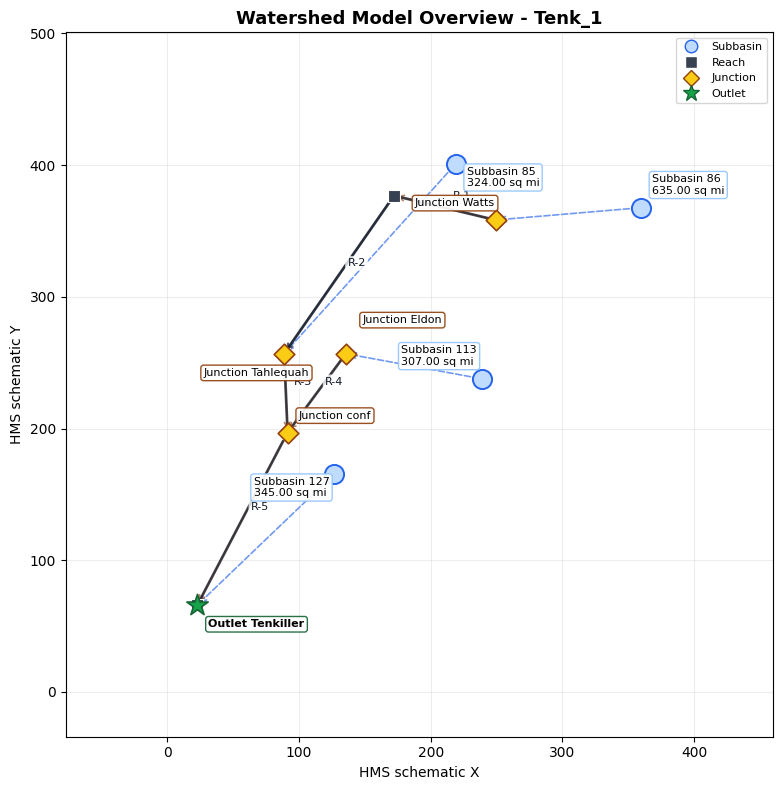

In [4]:
# Watershed overview and model context
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
except ImportError as exc:
    print(f"Model context plot skipped: {exc}")
else:
    basin_file = next(Path(project_path).glob("*.basin"))
    subbasins_ctx = HmsBasin.get_subbasins(basin_file)
    met_files = sorted(Path(project_path).glob("*.met"))
    control_files = sorted(Path(project_path).glob("*.control"))
    junctions_ctx = HmsBasin.get_junctions(basin_file)
    reaches_ctx = HmsBasin.get_reaches(basin_file)
    reservoirs_ctx = HmsBasin.get_reservoirs(basin_file)
    sinks_ctx = HmsBasin.get_sinks(basin_file)

    context_rows = [
        {"Component": "Basin file", "Count": 1, "Details": basin_file.name},
        {"Component": "Subbasins", "Count": len(subbasins_ctx), "Details": f"Total area {float(subbasins_ctx['area'].sum()):.2f} sq mi" if "area" in subbasins_ctx else ""},
        {"Component": "Reaches", "Count": len(reaches_ctx), "Details": "Explicit routing reaches" if len(reaches_ctx) else "Direct subbasin-to-outlet routing"},
        {"Component": "Junctions", "Count": len(junctions_ctx), "Details": "Confluences and outlet junctions"},
        {"Component": "Reservoirs", "Count": len(reservoirs_ctx), "Details": "Storage elements"},
        {"Component": "Sinks", "Count": len(sinks_ctx), "Details": "Terminal outlets"},
        {"Component": "Meteorologic models", "Count": len(met_files), "Details": ", ".join(path.stem for path in met_files)},
        {"Component": "Control specs", "Count": len(control_files), "Details": ", ".join(path.stem for path in control_files)},
    ]
    display(pd.DataFrame(context_rows))

    fig, ax = plt.subplots(figsize=(11, 8))
    coords = {}
    bounds_x = []
    bounds_y = []

    def add_point(name, x, y):
        coords[str(name)] = (float(x), float(y))
        bounds_x.append(float(x))
        bounds_y.append(float(y))

    def add_coords(df):
        for _, row in df.iterrows():
            try:
                add_point(row["name"], row["canvas_x"], row["canvas_y"])
            except (KeyError, TypeError, ValueError):
                continue

    for frame in (subbasins_ctx, junctions_ctx, reaches_ctx, reservoirs_ctx, sinks_ctx):
        add_coords(frame)

    def draw_connection(start_name, end_name, color="#6b7280", linestyle="-", linewidth=1.4):
        if start_name in coords and end_name in coords:
            x0, y0 = coords[start_name]
            x1, y1 = coords[end_name]
            if abs(x0 - x1) + abs(y0 - y1) > 1e-6:
                ax.annotate(
                    "",
                    xy=(x1, y1),
                    xytext=(x0, y0),
                    arrowprops={"arrowstyle": "->", "color": color, "lw": linewidth, "linestyle": linestyle, "alpha": 0.65},
                    zorder=1,
                )

    for _, row in subbasins_ctx.iterrows():
        downstream = str(row.get("downstream", ""))
        if downstream and downstream.lower() not in {"nan", "none"}:
            draw_connection(str(row.get("name", "")), downstream, color="#2563eb", linestyle="--", linewidth=1.2)

    for _, row in reaches_ctx.iterrows():
        name = str(row.get("name", ""))
        if {"from_canvas_x", "from_canvas_y", "canvas_x", "canvas_y"}.issubset(row.index):
            try:
                x0, y0 = float(row["from_canvas_x"]), float(row["from_canvas_y"])
                x1, y1 = float(row["canvas_x"]), float(row["canvas_y"])
                bounds_x.extend([x0, x1])
                bounds_y.extend([y0, y1])
                ax.plot([x0, x1], [y0, y1], color="#111827", linewidth=2.0, alpha=0.75, zorder=2)
                ax.annotate(name, ((x0 + x1) / 2, (y0 + y1) / 2), xytext=(6, 6), textcoords="offset points", fontsize=8, color="#111827", bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.8})
            except (TypeError, ValueError):
                pass
        downstream = str(row.get("downstream", ""))
        if downstream and downstream.lower() not in {"nan", "none"}:
            draw_connection(name, downstream, color="#111827", linewidth=1.5)

    for _, row in junctions_ctx.iterrows():
        downstream = str(row.get("downstream", ""))
        if downstream and downstream.lower() not in {"nan", "none"}:
            draw_connection(str(row.get("name", "")), downstream, color="#92400e", linewidth=1.2)

    label_offsets = [(8, 10), (8, -16), (-58, 10), (-58, -16), (12, 22)]

    for idx, (_, row) in enumerate(subbasins_ctx.iterrows()):
        name = str(row.get("name", ""))
        if name not in coords:
            continue
        x, y = coords[name]
        ax.scatter(x, y, s=190, marker="o", facecolor="#bfdbfe", edgecolor="#2563eb", linewidth=1.4, zorder=4)
        area_text = f"\n{float(row['area']):.2f} sq mi" if "area" in row and pd.notna(row["area"]) else ""
        dx, dy = label_offsets[idx % len(label_offsets)]
        ax.annotate(f"Subbasin {name}{area_text}", (x, y), xytext=(dx, dy), textcoords="offset points", fontsize=8, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#93c5fd", "alpha": 0.92}, zorder=6)

    for _, row in reaches_ctx.iterrows():
        name = str(row.get("name", ""))
        if name in coords:
            x, y = coords[name]
            ax.scatter(x, y, s=70, marker="s", facecolor="#374151", edgecolor="white", linewidth=0.8, zorder=5)

    for idx, (_, row) in enumerate(junctions_ctx.iterrows()):
        name = str(row.get("name", ""))
        if name not in coords:
            continue
        x, y = coords[name]
        downstream = str(row.get("downstream", ""))
        is_outlet = downstream.lower() in {"", "nan", "none"}
        marker = "*" if is_outlet else "D"
        color = "#16a34a" if is_outlet else "#facc15"
        edge = "#166534" if is_outlet else "#92400e"
        size = 260 if is_outlet else 110
        ax.scatter(x, y, s=size, marker=marker, facecolor=color, edgecolor=edge, linewidth=1.2, zorder=7)
        dx, dy = label_offsets[(idx + 2) % len(label_offsets)]
        label = f"Outlet {name}" if is_outlet else f"Junction {name}"
        ax.annotate(label, (x, y), xytext=(dx, dy), textcoords="offset points", fontsize=8, weight="bold" if is_outlet else "normal", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": edge, "alpha": 0.92}, zorder=8)

    for _, row in reservoirs_ctx.iterrows():
        name = str(row.get("name", ""))
        if name in coords:
            x, y = coords[name]
            ax.scatter(x, y, s=120, marker="h", facecolor="#a78bfa", edgecolor="#5b21b6", linewidth=1.2, zorder=6)
            ax.annotate(f"Reservoir {name}", (x, y), xytext=(8, 10), textcoords="offset points", fontsize=8, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#a78bfa", "alpha": 0.92})

    if coords:
        pad_x = max((max(bounds_x) - min(bounds_x)) * 0.22, 100.0)
        pad_y = max((max(bounds_y) - min(bounds_y)) * 0.22, 100.0)
        ax.set_xlim(min(bounds_x) - pad_x, max(bounds_x) + pad_x)
        ax.set_ylim(min(bounds_y) - pad_y, max(bounds_y) + pad_y)
        ax.set_aspect("equal", adjustable="box")

    legend_items = [
        Line2D([0], [0], marker="o", color="w", label="Subbasin", markerfacecolor="#bfdbfe", markeredgecolor="#2563eb", markersize=9),
        Line2D([0], [0], marker="s", color="w", label="Reach", markerfacecolor="#374151", markersize=8),
        Line2D([0], [0], marker="D", color="w", label="Junction", markerfacecolor="#facc15", markeredgecolor="#92400e", markersize=8),
        Line2D([0], [0], marker="*", color="w", label="Outlet", markerfacecolor="#16a34a", markeredgecolor="#166534", markersize=12),
    ]
    ax.legend(handles=legend_items, loc="upper right", frameon=True, fontsize=8)
    ax.set_title(f"Watershed Model Overview - {basin_file.stem}", fontsize=13, weight="bold")
    ax.set_xlabel("HMS schematic X")
    ax.set_ylabel("HMS schematic Y")
    ax.grid(True, alpha=0.22)
    plt.tight_layout()
    plt.show()

## 2. Read All Loss Parameters

Instead of calling `get_loss_parameters()` for each subbasin individually,
`get_all_loss_parameters()` returns a single DataFrame with one row per subbasin.
Parameters not applicable to a subbasin's loss method appear as NaN.

In [5]:
loss_df = HmsBasin.get_all_loss_parameters(basin_file)

print(f"Shape: {loss_df.shape[0]} subbasins x {loss_df.shape[1]} columns")
loss_methods = ", ".join(map(str, loss_df['loss_method'].dropna().unique()))
print(f"Loss methods: {loss_methods}")
print()

# Show the relevant columns (drop all-NaN columns for display)
display_df = loss_df.dropna(axis=1, how='all')
display_df

Shape: 4 subbasins x 22 columns
Loss methods: Initial+Constant



,name,area,loss_method,percent_impervious,initial_loss
0,86,635.0,Initial+Constant,0.0,1.00
1,85,324.0,Initial+Constant,0.0,1.00
2,113,307.0,Initial+Constant,0.0,1.30
3,127,345.0,Initial+Constant,10.0,1.15


## 3. Read All Transform Parameters

In [6]:
transform_df = HmsBasin.get_all_transform_parameters(basin_file)

transform_methods = ", ".join(map(str, transform_df['transform_method'].dropna().unique()))
print(f"Transform methods: {transform_methods}")
transform_df.dropna(axis=1, how='all')

Transform methods: Modified Clark


,name,area,transform_method,time_of_concentration,storage_coefficient
0,86,635.0,Modified Clark,24.0,11.6
1,85,324.0,Modified Clark,30.0,15.5
2,113,307.0,Modified Clark,18.0,8.7
3,127,345.0,Modified Clark,1.0,7.0


## 4. Read All Routing Parameters

In [7]:
routing_df = HmsBasin.get_all_routing_parameters(basin_file)

routing_methods = ", ".join(map(str, routing_df['route_method'].dropna().unique()))
print(f"Routing methods: {routing_methods}")
routing_df.dropna(axis=1, how='all')

Routing methods: Modified Puls, Lag


,name,route_method,number_of_reaches,storage_outflow_table_name,initial_variable,channel_loss,lag
0,R-1,Modified Puls,6.0,Table 4,Combined Inflow,None,NaN
1,R-2,Modified Puls,20.0,Table 3,Combined Inflow,None,NaN
2,R-3,Modified Puls,4.0,Table 1,Combined Inflow,None,NaN
3,R-4,Modified Puls,4.0,Table 2,Combined Inflow,None,NaN
4,R-5,Lag,NaN,NaN,Combined Inflow,None,120.0


## 5. Read All Baseflow Parameters

In [8]:
baseflow_df = HmsBasin.get_all_baseflow_parameters(basin_file)

baseflow_methods = ", ".join(map(str, baseflow_df['baseflow_method'].dropna().unique()))
print(f"Baseflow methods: {baseflow_methods}")
baseflow_df.dropna(axis=1, how='all')

Baseflow methods: Recession


,name,area,baseflow_method,recession_factor
0,86,635.0,Recession,0.79
1,85,324.0,Recession,0.79
2,113,307.0,Recession,0.79
3,127,345.0,Recession,0.79


## 6. Modify Parameters in Bulk

Edit the DataFrame, then write it back. Only non-NaN values that differ
from the file are written. A `.bak` backup is created automatically.

### Example: Increase initial loss by 20% for all subbasins

In [9]:
# Read current values
loss_df = HmsBasin.get_all_loss_parameters(basin_file)

print("Before:")
print(loss_df[['name', 'initial_loss']].to_string(index=False))

# Modify: increase initial_loss by 20%
loss_df['initial_loss'] = loss_df['initial_loss'] * 1.2

print("\nAfter (DataFrame):")
print(loss_df[['name', 'initial_loss']].to_string(index=False))

Before:
name  initial_loss
  86          1.00
  85          1.00
 113          1.30
 127          1.15

After (DataFrame):
name  initial_loss
  86          1.20
  85          1.20
 113          1.56
 127          1.38


In [10]:
# Write changes back to the basin file
result = HmsBasin.set_all_loss_parameters(basin_file, loss_df, create_backup=True)

print(f"Elements modified: {result['elements_modified']}")
print(f"Parameters changed: {result['parameters_changed']}")
print(f"Backup created: {display_path(result['backup_path'])}")

if result['elements_not_found']:
    print(f"Not found: {result['elements_not_found']}")
if result['warnings']:
    print(f"Warnings: {result['warnings']}")

Elements modified: 4
Parameters changed: 4
Backup created: hms_example_projects/tenk_batch/tenk/Tenk_1.basin.bak


In [11]:
# Verify: read back and confirm
verify_df = HmsBasin.get_all_loss_parameters(basin_file)

print("Verified from file:")
print(verify_df[['name', 'initial_loss']].to_string(index=False))

Verified from file:
name  initial_loss
  86          1.20
  85          1.20
 113          1.56
 127          1.38


### Idempotent Writes

Setting the same values again produces zero changes — the setter compares
numerically, so `"1"` (integer in file) equals `1.0` (float in DataFrame).

In [12]:
# Write the same values again — should report 0 changes
result = HmsBasin.set_all_loss_parameters(basin_file, verify_df, create_backup=False)

print(f"Parameters changed: {result['parameters_changed']}  (expected: 0)")

Parameters changed: 0  (expected: 0)


### Partial Updates (NaN = Skip)

You can update a single parameter for a single subbasin. Columns not in the
DataFrame (or with NaN values) are left unchanged.

In [13]:
import pandas as pd

# Update only percent_impervious for subbasin 127
partial_df = pd.DataFrame({
    'name': ['127'],
    'percent_impervious': [15.0]  # was 10.0
})

result = HmsBasin.set_all_loss_parameters(basin_file, partial_df, create_backup=False)
print(f"Changed: {result['parameters_changed']} parameter(s) in {result['elements_modified']} element(s)")

# Verify only that value changed
check = HmsBasin.get_all_loss_parameters(basin_file)
print(check[['name', 'percent_impervious', 'initial_loss']].to_string(index=False))

Changed: 1 parameter(s) in 1 element(s)
name  percent_impervious  initial_loss
  86                 0.0          1.20
  85                 0.0          1.20
 113                 0.0          1.56
 127                15.0          1.38


## 7. CSV Roundtrip: Export → Edit in Excel → Import

The most common batch workflow: export all parameters to CSV, edit in Excel
or a text editor, then import the changes back.

### Export

In [14]:
# Reset to fresh copy first
shutil.rmtree(project_path, ignore_errors=True)
project_path = HmsExamples.extract_project(
    "tenk",
    output_path=Path.cwd() / 'hms_example_projects' / 'tenk_batch'
)
basin_file = next(Path(project_path).glob('*.basin'))

# Export all parameter types to CSV
csv_dir = Path.cwd() / 'hms_example_projects' / 'tenk_batch_csv'
csv_dir.mkdir(exist_ok=True)
csv_path = csv_dir / 'tenk_params.csv'

HmsBasin.export_parameters_csv(basin_file, csv_path)

# Show what files were created
print("Exported CSV files:")
for f in sorted(csv_dir.glob('tenk_params*.csv')):
    print(f"  {f.name} ({f.stat().st_size:,} bytes)")

Exported CSV files:
  tenk_params.csv (1,368 bytes)
  tenk_params_baseflow.csv (830 bytes)
  tenk_params_loss.csv (763 bytes)
  tenk_params_routing.csv (953 bytes)
  tenk_params_transform.csv (543 bytes)


In [15]:
# Peek at the loss CSV
loss_csv = csv_dir / 'tenk_params_loss.csv'
print(f"Contents of {loss_csv.name}:")
print(loss_csv.read_text()[:500])

Contents of tenk_params_loss.csv:
# HMS Basin Parameters - loss
# Source: Tenk_1.basin
# Exported: 2026-06-14 09:48:13
# Import with: HmsBasin.import_parameters_csv("Tenk_1.basin", "tenk_params_loss.csv")
param_type,name,area,loss_method,percent_impervious,initial_loss,moisture_deficit,wetting_front_suction,hydraulic_conductivity,initial_variable,initial_deficit,maximum_deficit,constant_rate,percolation_rate,curve_number,initial_abstraction,initial_rate,saturated_conductivity,wetting_front_capillary,soil,groundwater_1,groundwate


### Import (No Modifications = Zero Changes)

In [16]:
# Import the unmodified CSV — should produce 0 changes
result = HmsBasin.import_parameters_csv(basin_file, csv_path, create_backup=True)

for ptype, summary in result.items():
    print(f"{ptype}: {summary['elements_modified']} modified, "
          f"{summary['parameters_changed']} params changed")

baseflow: 0 modified, 0 params changed


loss: 0 modified, 0 params changed
routing: 0 modified, 0 params changed
transform: 0 modified, 0 params changed


### Import After Editing

Simulate what happens after a user edits the CSV in Excel.

In [17]:
import pandas as pd

# Read the loss CSV, modify a value, and write it back
edited_df = pd.read_csv(loss_csv, comment='#')

# Simulate an engineer changing initial_loss for subbasin 113
edited_df.loc[edited_df['name'].astype(str) == '113', 'initial_loss'] = 2.0

# Write modified CSV (preserving comment headers)
header = [line for line in loss_csv.read_text().split('\n') if line.startswith('#')]
csv_text = edited_df.to_csv(index=False)
loss_csv.write_text('\n'.join(header) + '\n' + csv_text)

print("Modified CSV (initial_loss for 113 changed to 2.0):")
print(edited_df[['name', 'initial_loss']].to_string(index=False))

Modified CSV (initial_loss for 113 changed to 2.0):
 name  initial_loss
   86          1.00
   85          1.00
  113          2.00
  127          1.15


In [18]:
# Import the modified loss CSV
result = HmsBasin.import_parameters_csv(basin_file, loss_csv, create_backup=False)

for ptype, summary in result.items():
    print(f"{ptype}: {summary['elements_modified']} modified, "
          f"{summary['parameters_changed']} params changed")

# Verify
check = HmsBasin.get_all_loss_parameters(basin_file)
print(f"\nVerified initial_loss for 113: {check.loc[check['name'] == '113', 'initial_loss'].values[0]}")

loss: 1 modified, 1 params changed

Verified initial_loss for 113: 2.0


## 8. Batch Met Operations: Gage Assignments

`HmsMet.set_all_gage_assignments()` is the batch write counterpart to
`get_gage_assignments()`. It updates precipitation gage assignments for
multiple subbasins in a single call.

In [19]:
# Find the met file
met_files = list(Path(project_path).glob('*.met'))
if met_files:
    met_file = met_files[0]
    print(f"Met file: {met_file.name}")
    
    # Read current assignments
    assignments = HmsMet.get_gage_assignments(met_file)
    print(f"\nCurrent gage assignments ({len(assignments)} subbasins):")
    display(assignments)
else:
    print("No met file found in project")

Met file: Stage3_HRAP.met

Current gage assignments (4 subbasins):


,subbasin,precip_gage,weight
0,113,None,1.0
1,127,None,1.0
2,85,None,1.0
3,86,None,1.0


In [20]:
if met_files and not assignments.empty:
    # Write back unchanged — should report 0 modifications
    result = HmsMet.set_all_gage_assignments(met_file, assignments, create_backup=False)
    print(f"Subbasins modified: {result['subbasins_modified']}  (expected: 0)")
    
    if result['subbasins_not_found']:
        print(f"Not found: {result['subbasins_not_found']}")

Subbasins modified: 0  (expected: 0)


## 9. Cleanup

In [21]:
# Remove extracted example projects
shutil.rmtree(Path.cwd() / 'hms_example_projects' / 'tenk_batch', ignore_errors=True)
shutil.rmtree(Path.cwd() / 'hms_example_projects' / 'tenk_batch_csv', ignore_errors=True)
print("Cleaned up temporary files")

Cleaned up temporary files


## Summary

| Operation | Method | Input | Output |
|-----------|--------|-------|--------|
| Read all loss params | `get_all_loss_parameters()` | basin path | DataFrame |
| Read all transform params | `get_all_transform_parameters()` | basin path | DataFrame |
| Read all baseflow params | `get_all_baseflow_parameters()` | basin path | DataFrame |
| Read all routing params | `get_all_routing_parameters()` | basin path | DataFrame |
| Write params from DataFrame | `set_all_*_parameters()` | basin path + DataFrame | summary dict |
| Export to CSV | `export_parameters_csv()` | basin path + CSV path | CSV files |
| Import from CSV | `import_parameters_csv()` | basin path + CSV path | summary dict |
| Batch gage assignments | `HmsMet.set_all_gage_assignments()` | met path + DataFrame | summary dict |

**Key Design Decisions**:
- **NaN = skip**: Only non-NaN values are written, making partial updates safe
- **Idempotent**: Setting the same values reports 0 changes (numeric comparison)
- **Auto-backup**: `.bak` file created before any write (`create_backup=True` default)
- **Summary dict**: Every write returns counts of what changed

## Next Steps

- **03_file_ops_basin_met_control_gage.ipynb**: Single-element file operations
- **05_clone_workflow.ipynb**: Non-destructive cloning for QAQC
- **15_upstream_network_analysis.ipynb**: Network traversal and drainage areas